# Q4: Polynomial Regression and Ridge Regularization

## Introduction
In this notebook, we explore polynomial regression and ridge regularization. 
- **Part A:** Visualizing polynomial fits of different degrees ($d=1, 3, 9$) on `data_A`.
- **Part B:** Studying the effect of polynomial degree and ridge regularization parameter ($\lambda$) on training and validation errors using `data_B` (split into training and validation sets).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
def get_poly_features(x, degree):
    X_poly = np.ones((len(x), 1))
    for d in range(1, degree + 1):
        X_poly = np.hstack((X_poly, (x**d).reshape(-1, 1)))
    return X_poly

def fit_linear_regression(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

def fit_ridge_regression(X, y, lamb):
    I = np.eye(X.shape[1])
    return np.linalg.inv(X.T @ X + lamb * I) @ X.T @ y

def predict(X, theta):
    return X @ theta

def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [5]:
df_a = pd.read_csv('data_A.csv')
X_a_raw = df_a['x'].values
y_a = df_a['y'].values

df_b_train = pd.read_csv('data_B_train.csv')
X_b_train_raw = df_b_train['x'].values
y_b_train = df_b_train['y'].values

df_b_val = pd.read_csv('data_B_val.csv')
X_b_val_raw = df_b_val['x'].values
y_b_val = df_b_val['y'].values

print(f"Data A size: {len(X_a_raw)}")
print(f"Data B Train size: {len(X_b_train_raw)}")
print(f"Data B Val size: {len(X_b_val_raw)}")

Data A size: 200
Data B Train size: 20
Data B Val size: 20


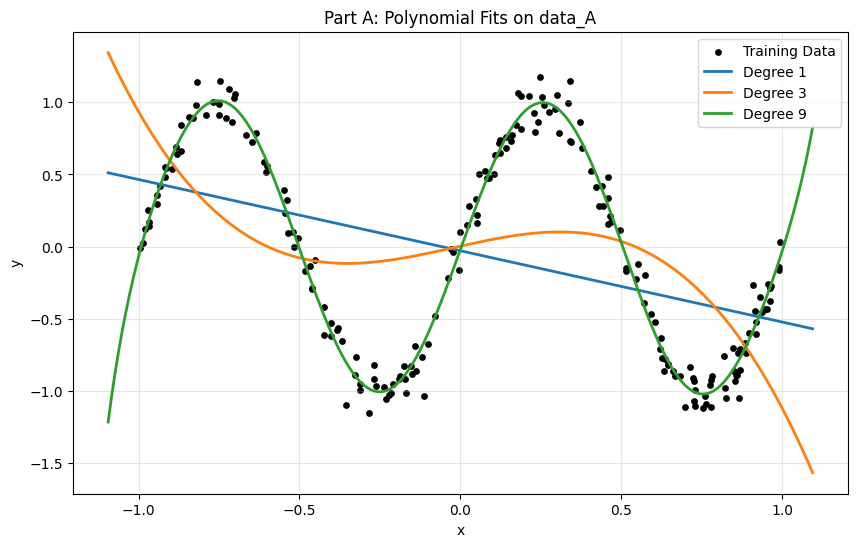

In [6]:
degrees_a = [1, 3, 9]

plt.figure(figsize=(10, 6))
plt.scatter(X_a_raw, y_a, color='black', label='Training Data', s=15)

x_grid = np.linspace(X_a_raw.min() - 0.1, X_a_raw.max() + 0.1, 200)

for d in degrees_a:
    X_d = get_poly_features(X_a_raw, d)
    theta = fit_linear_regression(X_d, y_a)
    X_grid_design = get_poly_features(x_grid, d)
    y_pred_grid = predict(X_grid_design, theta)
    
    plt.plot(x_grid, y_pred_grid, label=f'Degree {d}', linewidth=2)

plt.title('Part A: Polynomial Fits on data_A')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observations for Part A
- **Degree 1:** Clearly **underfits** the data. The relationship is non-linear, and a straight line fails to capture the curvature.
- **Degree 3:** Appears to follow the trend of the data points quite well without excessive wiggling.
- **Degree 9:** Depending on the exact noise in the data, degree 9 might start to show signs of **overfitting** (wiggling to pass near specific points) or unnecessary complexity, although if the data is relatively low noise, it might look similar to degree 3. If there are oscillations between data points, that is a sign of high variance.

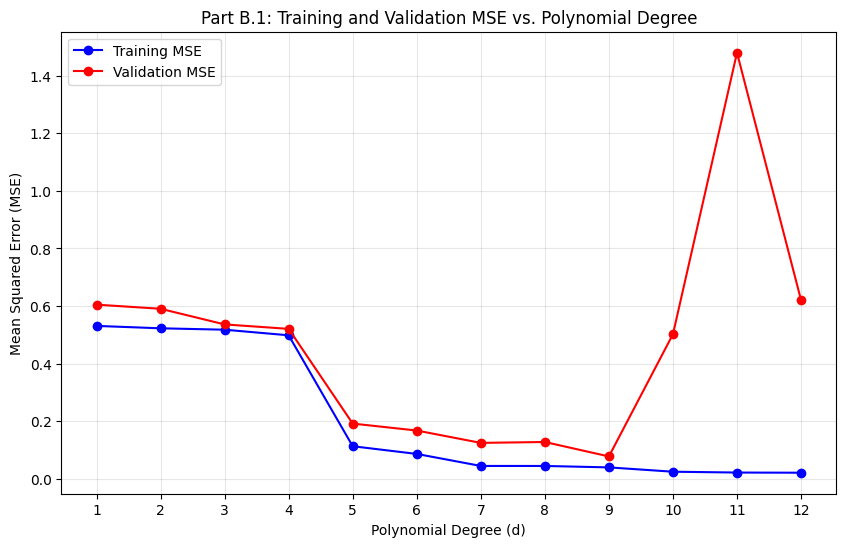

In [7]:
degrees_b = range(1, 13)
train_mses = []
val_mses = []

for d in degrees_b:
    X_train_poly = get_poly_features(X_b_train_raw, d)
    X_val_poly = get_poly_features(X_b_val_raw, d)
    theta = fit_linear_regression(X_train_poly, y_b_train)
    y_train_pred = predict(X_train_poly, theta)
    y_val_pred = predict(X_val_poly, theta)
    train_mses.append(calculate_mse(y_b_train, y_train_pred))
    val_mses.append(calculate_mse(y_b_val, y_val_pred))

plt.figure(figsize=(10, 6))
plt.plot(degrees_b, train_mses, 'o-', label='Training MSE', color='blue')
plt.plot(degrees_b, val_mses, 'o-', label='Validation MSE', color='red')
plt.xlabel('Polynomial Degree (d)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Part B.1: Training and Validation MSE vs. Polynomial Degree')
plt.xticks(degrees_b)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observations for Part B.1
- Underfitting: Low degrees (e.g., $d=1, 2$) likely show high MSE for both training and validation, indicating the model is too simple to capture the underlying pattern.
- Overfitting: As the degree increases significantly (e.g., $d > 7$ or $8$), the Training MSE continues to decrease (or stay low), but the Validation MSE starts to rise drastically. This divergence signals overfitting.
- Best Trade-off: The degree where difference between Validation MSE and Training MSE is relatively small and Validation MSE is minimal represents the best trade-off. This is often around $d=3$ to $d=6$ for simple polynomial data, but depends on the specific noise and meaningful complexity of `data_B`.

In [7]:
lambdas = np.logspace(-6, 2, 50)
lambdas

array([1.00000000e-06, 1.45634848e-06, 2.12095089e-06, 3.08884360e-06,
       4.49843267e-06, 6.55128557e-06, 9.54095476e-06, 1.38949549e-05,
       2.02358965e-05, 2.94705170e-05, 4.29193426e-05, 6.25055193e-05,
       9.10298178e-05, 1.32571137e-04, 1.93069773e-04, 2.81176870e-04,
       4.09491506e-04, 5.96362332e-04, 8.68511374e-04, 1.26485522e-03,
       1.84206997e-03, 2.68269580e-03, 3.90693994e-03, 5.68986603e-03,
       8.28642773e-03, 1.20679264e-02, 1.75751062e-02, 2.55954792e-02,
       3.72759372e-02, 5.42867544e-02, 7.90604321e-02, 1.15139540e-01,
       1.67683294e-01, 2.44205309e-01, 3.55648031e-01, 5.17947468e-01,
       7.54312006e-01, 1.09854114e+00, 1.59985872e+00, 2.32995181e+00,
       3.39322177e+00, 4.94171336e+00, 7.19685673e+00, 1.04811313e+01,
       1.52641797e+01, 2.22299648e+01, 3.23745754e+01, 4.71486636e+01,
       6.86648845e+01, 1.00000000e+02])

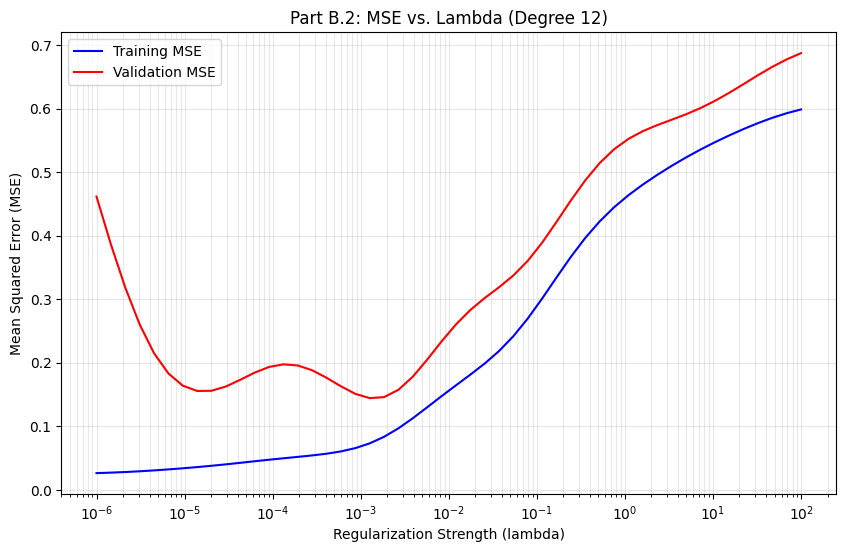

In [8]:
d_fixed = 12
X_train_poly_12 = get_poly_features(X_b_train_raw, d_fixed)
X_val_poly_12 = get_poly_features(X_b_val_raw, d_fixed)

lambdas = np.logspace(-6, 2, 50)
train_mses_ridge = []
val_mses_ridge = []

for lamb in lambdas:
    theta = fit_ridge_regression(X_train_poly_12, y_b_train, lamb)
    
    y_train_pred = predict(X_train_poly_12, theta)
    y_val_pred = predict(X_val_poly_12, theta)
    
    train_mses_ridge.append(calculate_mse(y_b_train, y_train_pred))
    val_mses_ridge.append(calculate_mse(y_b_val, y_val_pred))

plt.figure(figsize=(10, 6))
plt.semilogx(lambdas, train_mses_ridge, label='Training MSE', color='blue')
plt.semilogx(lambdas, val_mses_ridge, label='Validation MSE', color='red')
plt.xlabel('Regularization Strength (lambda)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'Part B.2: MSE vs. Lambda (Degree {d_fixed})')
plt.legend()
plt.grid(True, alpha=0.3, which="both", ls="-")
plt.show()

### Observations for Part B.2
- Small $\lambda$ (e.g., $10^{-6}$): The model behaves similarly to unregularized OLS with $d=12$. Since $d=12$ likely overfits, we expect low Training MSE but very high Validation MSE.
- Increasing $\lambda$: As $\lambda$ increases, the penalty on the magnitude of weights $\theta$ increases. This restricts the model's flexibility, reducing variance (overfitting). Consequently, Validation MSE should decrease initially.
- Optimum Range: There is an intermediate range of $\lambda$ where the Validation MSE reaches a minimum. This is the "sweet spot" where the model is regularized enough to ignore noise but still flexible enough to capture the trend.
- Large $\lambda$ (e.g., $10^2$): If $\lambda$ is too large, the model becomes too rigid (underfitting), driving weights towards zero. Both Training and Validation MSEs will increase as the model fails to capture the signal, eventually converging towards a horizontal line (bias only).

### Conclusion
- Complexity & Regularization: High-degree polynomials ($d=12$) provide enough capacity to model complex relationships but are prone to overfitting (high variance). Ridge regularization offers a way to control this complexity without explicitly reducing the degree $d$. By tuning $\lambda$, we effectively dampen the high-frequency oscillations associated with large polynomial coefficients, achieving a balance similar to choosing a lower degree model but with a smoother transition.



# Q10: Transfer Learning with Pre-trained Networks

In this problem, we compare a shallow neural network (MLP) trained from scratch with a deep pre-trained convolutional network (VGG-11) on the CIFAR-10 image classification task. All experiments are conducted on the CIFAR-10 dataset.

### 1. Data Pre-processing
We construct a pipeline to convert CIFAR-10 images to tensors and apply normalization using dataset-specific statistics.

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

batch_size = 512

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                           shuffle=True, num_workers=2)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Train data size: {len(train_set)}")
print(f"Test data size: {len(test_set)}")

Using device: cpu


100%|██████████| 170M/170M [00:23<00:00, 7.15MB/s] 


Train data size: 50000
Test data size: 10000


In [2]:
class MLP(nn.Module):
    def __init__(self, input_dim=32*32*3, hidden_dim=1024, num_classes=10):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

def get_vgg_model(frozen=True):
    try:
        weights = models.VGG11_Weights.IMAGENET1K_V1
        model = models.vgg11(weights=weights)
    except:
        model = models.vgg11(pretrained=True)

    if frozen:
        for param in model.features.parameters():
            param.requires_grad = False
    
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, 10)
    
    return model

model_mlp = MLP().to(device)
model_frozen_vgg = get_vgg_model(frozen=True).to(device)
model_finetuned_vgg = get_vgg_model(frozen=False).to(device)

print("Models initialized.")

Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /Users/majidsadeghinejad/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


100%|██████████| 507M/507M [01:16<00:00, 6.94MB/s] 


Models initialized.


In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []

    print(f"Starting training for {name}...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        val_accuracies.append(accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} | Val Acc: {accuracy:.2f}%")

    return train_losses, val_accuracies

epochs = 10
lr = 1e-3

print("\n--- Model 1: MLP Baseline ---")
loss_mlp, acc_mlp = train_model(model_mlp, train_loader, test_loader, epochs, lr, "MLP")

print("\n--- Model 2: Frozen VGG-11 ---")
loss_frozen, acc_frozen = train_model(model_frozen_vgg, train_loader, test_loader, epochs, lr, "Frozen VGG")

print("\n--- Model 3: Fine-Tuned VGG-11 ---")
loss_finetuned, acc_finetuned = train_model(model_finetuned_vgg, train_loader, test_loader, epochs, 1e-4, "Fine-Tuned VGG")


--- Model 1: MLP Baseline ---
Starting training for MLP...
Epoch [1/10] Loss: 1.6638 | Val Acc: 46.61%
Epoch [2/10] Loss: 1.4265 | Val Acc: 49.42%
Epoch [3/10] Loss: 1.3022 | Val Acc: 51.16%
Epoch [4/10] Loss: 1.2038 | Val Acc: 52.33%
Epoch [5/10] Loss: 1.1089 | Val Acc: 52.40%
Epoch [6/10] Loss: 1.0219 | Val Acc: 52.74%
Epoch [7/10] Loss: 0.9419 | Val Acc: 53.57%
Epoch [8/10] Loss: 0.8584 | Val Acc: 53.53%
Epoch [9/10] Loss: 0.7648 | Val Acc: 53.32%
Epoch [10/10] Loss: 0.6850 | Val Acc: 54.10%

--- Model 2: Frozen VGG-11 ---
Starting training for Frozen VGG...
Epoch [1/10] Loss: 1.2365 | Val Acc: 66.46%
Epoch [2/10] Loss: 1.0179 | Val Acc: 69.02%
Epoch [3/10] Loss: 0.9634 | Val Acc: 67.57%
Epoch [4/10] Loss: 0.9295 | Val Acc: 69.52%
Epoch [5/10] Loss: 0.8900 | Val Acc: 69.76%
Epoch [6/10] Loss: 0.8555 | Val Acc: 70.89%
Epoch [7/10] Loss: 0.8242 | Val Acc: 71.10%
Epoch [8/10] Loss: 0.7952 | Val Acc: 71.56%
Epoch [9/10] Loss: 0.7795 | Val Acc: 71.48%
Epoch [10/10] Loss: 0.7478 | Val Ac

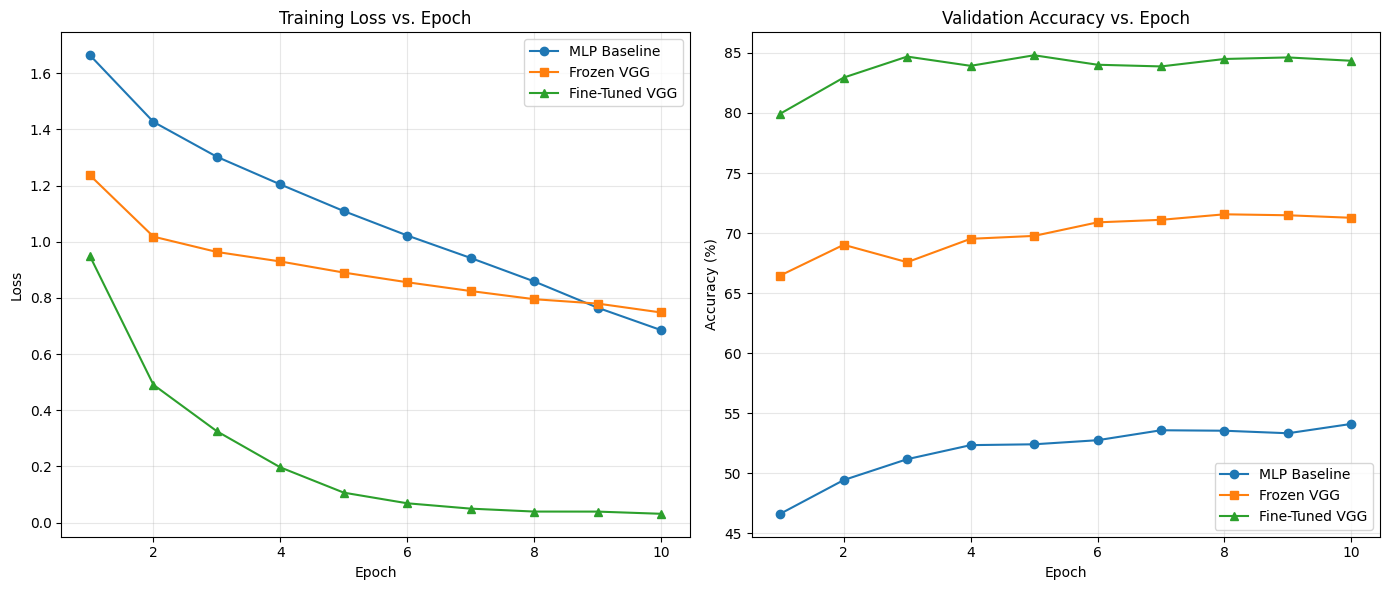

In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss_mlp, label='MLP Baseline', marker='o')
plt.plot(epochs_range, loss_frozen, label='Frozen VGG', marker='s')
plt.plot(epochs_range, loss_finetuned, label='Fine-Tuned VGG', marker='^')
plt.title('Training Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc_mlp, label='MLP Baseline', marker='o')
plt.plot(epochs_range, acc_frozen, label='Frozen VGG', marker='s')
plt.plot(epochs_range, acc_finetuned, label='Fine-Tuned VGG', marker='^')
plt.title('Validation Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()